# hn24 EDA — 파일2 (설문 + 혈액검사) · 성인 한정 (19세 이상)
기본 통계량 → Y값별 분포 비교 → 결측 패턴 → 변수간 상관관계

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from matplotlib import rc
from scipy import stats
import os

matplotlib.rcParams['axes.unicode_minus'] = False
rc('font', family='AppleGothic')

OUTPUT_DIR = '/Users/admin/PycharmProjects/chronic-health/outputs_file2_adult'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_raw = pd.read_csv('/Users/admin/PycharmProjects/chronic-health/data/hn24_file2_survey_blood.csv')
print(f'원본 shape: {df_raw.shape}')
df_raw.head()

원본 shape: (6997, 32)


,ID,sex,age,occp,HE_ht,HE_wt,HE_BMI,sm_presnt,BD1_11,BD2_1,...,HE_TG,HE_HDL_st2,HE_LDL_drct,HE_glu,HE_sbp,HE_dbp,DI1_pr,DE1_pr,DI2_pr,HE_obe
0,WA01257801,1.0,38.0,5.0,174.1,93.2,30.748106,1.0,0.0,0.0,...,337.0,26.0,115.0,100.0,123.5,80.5,0.0,0.0,0.0,5.0
1,WA01257802,2.0,34.0,2.0,162.9,62.4,23.514861,0.0,5.0,3.0,...,51.0,60.0,142.0,91.0,109.5,78.0,0.0,0.0,0.0,3.0
2,WA01257803,1.0,6.0,NaN,114.1,20.8,15.976883,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,89.0,55.0,0.0,0.0,0.0,NaN
3,WA01257804,1.0,6.0,NaN,113.2,23.1,18.026820,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,107.5,61.5,0.0,0.0,0.0,NaN
4,WA01257805,2.0,4.0,NaN,93.1,14.4,16.613576,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN


In [2]:
# ── 변수명 한국어 매핑 ────────────────────────────────────────
col_rename = {
    'sex':          '성별',
    'age':          '나이',
    'occp':         '직업',
    'HE_ht':        '신장',
    'HE_wt':        '체중',
    'HE_BMI':       'BMI',
    'sm_presnt':    '현재흡연',
    'BD1_11':       '음주빈도',
    'BD2_1':        '음주량',
    'HE_HPfh1':     '고혈압가족력_부',
    'HE_HPfh2':     '고혈압가족력_모',
    'HE_HPfh3':     '고혈압가족력_형제',
    'HE_DMfh1':     '당뇨가족력_부',
    'HE_DMfh2':     '당뇨가족력_모',
    'HE_DMfh3':     '당뇨가족력_형제',
    'HE_HLfh1':     '고지혈증가족력_부',
    'HE_HLfh2':     '고지혈증가족력_모',
    'HE_HLfh3':     '고지혈증가족력_형제',
    'BE3_31':       '걷기일수',
    'BE5_1':        '근력운동일수',
    'HE_chol':      '총콜레스테롤',
    'HE_TG':        '중성지방',
    'HE_HDL_st2':   'HDL콜레스테롤',
    'HE_LDL_drct':  'LDL콜레스테롤',
    'HE_glu':       '공복혈당',
    'HE_sbp':       '수축기혈압',
    'HE_dbp':       '이완기혈압',
    'DI1_pr':       '고혈압유병',
    'DE1_pr':       '당뇨유병',
    'DI2_pr':       '이상지질혈증유병',
    'HE_obe':       '비만단계',
}

df_raw = df_raw.rename(columns=col_rename)
print('변수명 변경 완료')

변수명 변경 완료


In [3]:
# ── 소아 제거 (19세 미만 제외) ───────────────────────────────
before = len(df_raw)
df = df_raw[df_raw['나이'] >= 19].reset_index(drop=True)
after = len(df)
removed = before - after

print('=' * 45)
print(f'  소아 제거 (나이 < 19세) 결과')
print('=' * 45)
print(f'  원본:       {before:,}명')
print(f'  제거:       {removed:,}명 ({removed/before*100:.1f}%)')
print(f'  필터링 후:  {after:,}명')
print('=' * 45)
print(f'  나이 범위:  {df["나이"].min()}세 ~ {df["나이"].max()}세')
print()

# Y값별 유병 현황 변화 확인
print('=== Y값별 유병 현황 (필터링 후) ===')
for col, label in [('고혈압유병','고혈압'), ('당뇨유병','당뇨'), ('이상지질혈증유병','이상지질혈증')]:
    vc = df[col].value_counts().sort_index()
    n1 = vc.get(1, 0)
    n0 = vc.get(0, 0)
    ratio = n0 / n1 if n1 > 0 else float('inf')
    print(f'  {label}: 유병 {n1}명 ({n1/after*100:.1f}%) / 정상 {n0}명 → 불균형 1:{ratio:.1f}')

# 비만단계
obe_labels = {2:'정상', 3:'비만전단계', 4:'1단계', 5:'2단계', 6:'3단계'}
obe_vc = df['비만단계'].value_counts().sort_index()
print(f'  비만단계:')
for k, v in obe_vc.items():
    print(f'    {obe_labels.get(k, k)}: {v}명 ({v/after*100:.1f}%)')

  소아 제거 (나이 < 19세) 결과
  원본:       6,997명
  제거:       964명 (13.8%)
  필터링 후:  6,033명
  나이 범위:  19.0세 ~ 80.0세

=== Y값별 유병 현황 (필터링 후) ===
  고혈압: 유병 1680명 (27.8%) / 정상 4353명 → 불균형 1:2.6
  당뇨: 유병 811명 (13.4%) / 정상 5222명 → 불균형 1:6.4
  이상지질혈증: 유병 1558명 (25.8%) / 정상 4475명 → 불균형 1:2.9
  비만단계:
    정상: 2419명 (40.1%)
    비만전단계: 1329명 (22.0%)
    1단계: 1751명 (29.0%)
    2단계: 344명 (5.7%)
    3단계: 66명 (1.1%)


## 1. 기본 통계량

In [4]:
# ── 연속형 변수 상세 기술통계 ─────────────────────────────────
cont_cols = ['나이', '신장', '체중', 'BMI',
             '총콜레스테롤', '중성지방', 'HDL콜레스테롤', 'LDL콜레스테롤',
             '공복혈당', '수축기혈압', '이완기혈압']

summary = pd.DataFrame({
    'N':         df[cont_cols].count(),
    '결측수':     df[cont_cols].isnull().sum(),
    '결측률(%)':  (df[cont_cols].isnull().sum() / len(df) * 100).round(1),
    '평균':       df[cont_cols].mean().round(2),
    '중앙값':     df[cont_cols].median().round(2),
    '최빈값':     df[cont_cols].mode().iloc[0].round(2),
    '표준편차':   df[cont_cols].std().round(2),
    'IQR':       (df[cont_cols].quantile(0.75) - df[cont_cols].quantile(0.25)).round(2),
    '최솟값':     df[cont_cols].min().round(2),
    'Q1':        df[cont_cols].quantile(0.25).round(2),
    'Q3':        df[cont_cols].quantile(0.75).round(2),
    '최댓값':     df[cont_cols].max().round(2),
    '왜도':       df[cont_cols].skew().round(3),
    '첨도':       df[cont_cols].kurt().round(3),
})

print('=== 연속형 변수 상세 기술통계 (19세 이상) ===')
print(summary.T)
print()
print('※ 왜도 해석: |왜도| > 1 → 변환 고려, 양수=오른쪽 꼬리, 음수=왼쪽 꼬리')
print('※ 첨도 해석: > 0 뾰족한 분포, < 0 납작한 분포')

=== 연속형 변수 상세 기술통계 (19세 이상) ===
              나이        신장        체중       BMI    총콜레스테롤      중성지방  HDL콜레스테롤  \
N       6033.000  5925.000  5998.000  5925.000  5814.000  5814.000  5814.000   
결측수        0.000   108.000    35.000   108.000   219.000   219.000   219.000   
결측률(%)     0.000     1.800     0.600     1.800     3.600     3.600     3.600   
평균        54.160   163.430    64.820    24.140   186.930   126.920    58.450   
중앙값       56.000   163.000    63.000    23.750   185.000   104.000    56.000   
최빈값       80.000   162.400    65.300    20.670   152.000    81.000    55.000   
표준편차      17.170     9.430    13.660     3.880    40.300    97.230    15.840   
IQR       27.000    13.300    17.900     4.880    55.000    74.000    21.000   
최솟값       19.000   127.900    25.000    12.070    78.000    27.000    18.000   
Q1        41.000   156.700    54.900    21.460   158.000    75.000    47.000   
Q3        68.000   170.000    72.800    26.340   213.000   149.000    68.000   
최댓값     

In [5]:
# ── 범주형 변수 분포 (최빈값 + 엔트로피 포함) ────────────────
from scipy.stats import entropy

cat_cols = {
    '성별':     {1: '남자', 2: '여자'},
    '직업':     {1: '관리/전문', 2: '사무', 3: '서비스/판매', 4: '농림어업', 5: '기능/노무', 6: '주부·학생', 7: '무직'},
    '현재흡연': {0: '비흡연', 1: '현재흡연'},
    '음주빈도': {0: '비음주', 1: '월1회미만', 2: '월1회', 3: '월2-4회', 4: '주2-3회', 5: '주4회이상', 6: '최근1년안마심'},
}

print('=== 범주형 변수 분포 (19세 이상) ===')
for col, labels in cat_cols.items():
    vc = df[col].value_counts(dropna=True).sort_index()
    pct = (vc / vc.sum() * 100).round(1)
    mode_val = vc.idxmax()
    ent = entropy(pct / 100, base=2)

    new_index = [labels.get(i, str(i)) for i in vc.index]
    vc.index = new_index
    pct.index = new_index

    result = pd.DataFrame({'n': vc, '%': pct})
    print(f'\n{col} | 최빈값: {labels.get(mode_val, mode_val)} | 엔트로피: {ent:.3f}')
    print(result)

=== 범주형 변수 분포 (19세 이상) ===

성별 | 최빈값: 여자 | 엔트로피: 0.985
       n     %
남자  2582  42.8
여자  3451  57.2

직업 | 최빈값: 무직 | 엔트로피: 2.483
           n     %
관리/전문    847  15.5
사무       573  10.5
서비스/판매   795  14.5
농림어업     146   2.7
기능/노무    509   9.3
주부·학생    549  10.0
무직      2058  37.6

현재흡연 | 최빈값: 비흡연 | 엔트로피: 0.574
         n     %
비흡연   5023  86.4
현재흡연   792  13.6

음주빈도 | 최빈값: 주2-3회 | 엔트로피: 2.693
            n     %
비음주       596  10.2
월1회미만    1104  19.0
월1회      1151  19.8
월2-4회     667  11.5
주2-3회    1209  20.8
주4회이상     798  13.7
최근1년안마심   291   5.0


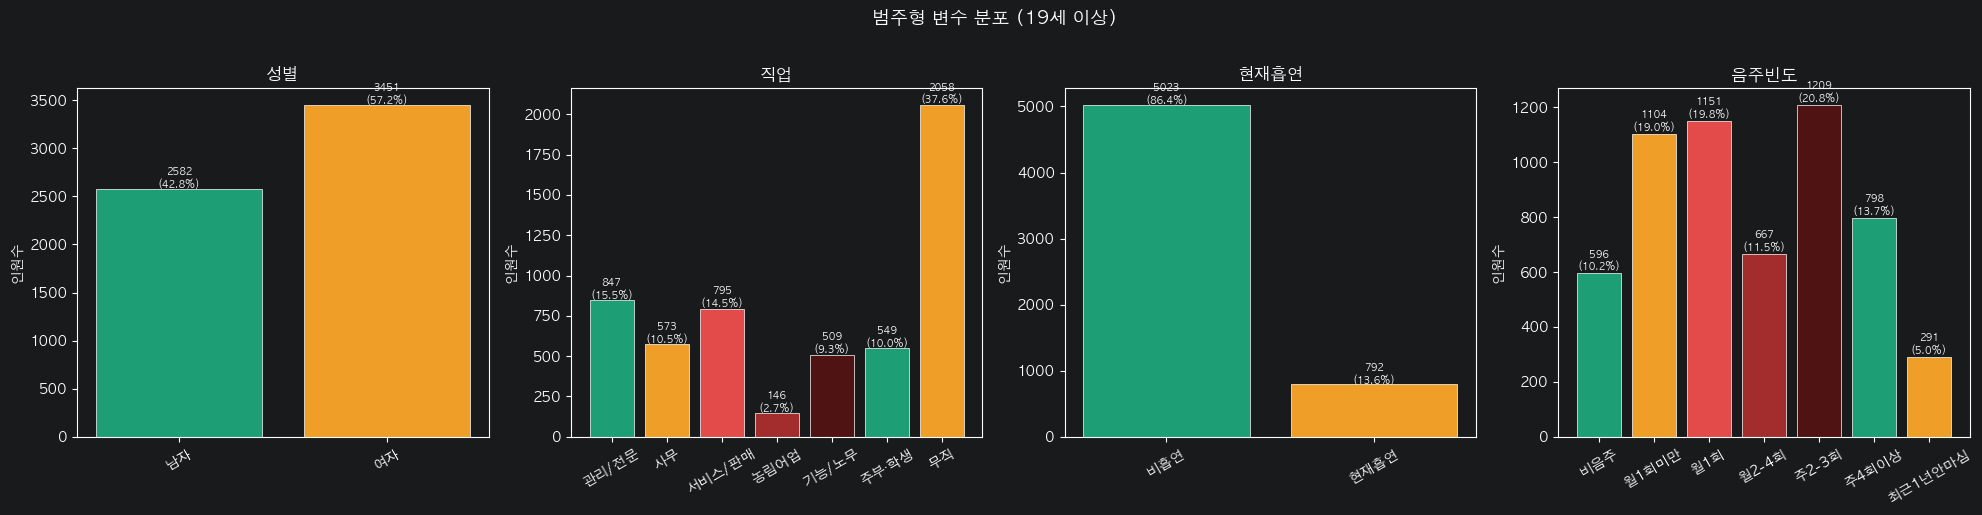

저장 완료: 01c_범주형변수분포.png


In [6]:
# ── 범주형 변수 분포 시각화 ──────────────────────────────────
cat_cols = {
    '성별':     {1: '남자', 2: '여자'},
    '직업':     {1: '관리/전문', 2: '사무', 3: '서비스/판매', 4: '농림어업', 5: '기능/노무', 6: '주부·학생', 7: '무직'},
    '현재흡연': {0: '비흡연', 1: '현재흡연'},
    '음주빈도': {0: '비음주', 1: '월1회미만', 2: '월1회', 3: '월2-4회', 4: '주2-3회', 5: '주4회이상', 6: '최근1년안마심'},
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (col, labels) in zip(axes, cat_cols.items()):
    vc = df[col].value_counts(dropna=True).sort_index()
    new_index = [labels.get(i, str(i)) for i in vc.index]
    pct = (vc / vc.sum() * 100).round(1)

    bars = ax.bar(new_index, vc.values, color=['#1D9E75', '#EF9F27', '#E24B4A', '#A32D2D', '#501313'], edgecolor='white', linewidth=0.5)
    ax.set_title(col, fontsize=12)
    ax.set_ylabel('인원수')
    ax.tick_params(axis='x', rotation=30)
    for bar, val, p in zip(bars, vc.values, pct.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val}\n({p}%)', ha='center', fontsize=7)

plt.suptitle('범주형 변수 분포 (19세 이상)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01c_범주형변수분포.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 01c_범주형변수분포.png')

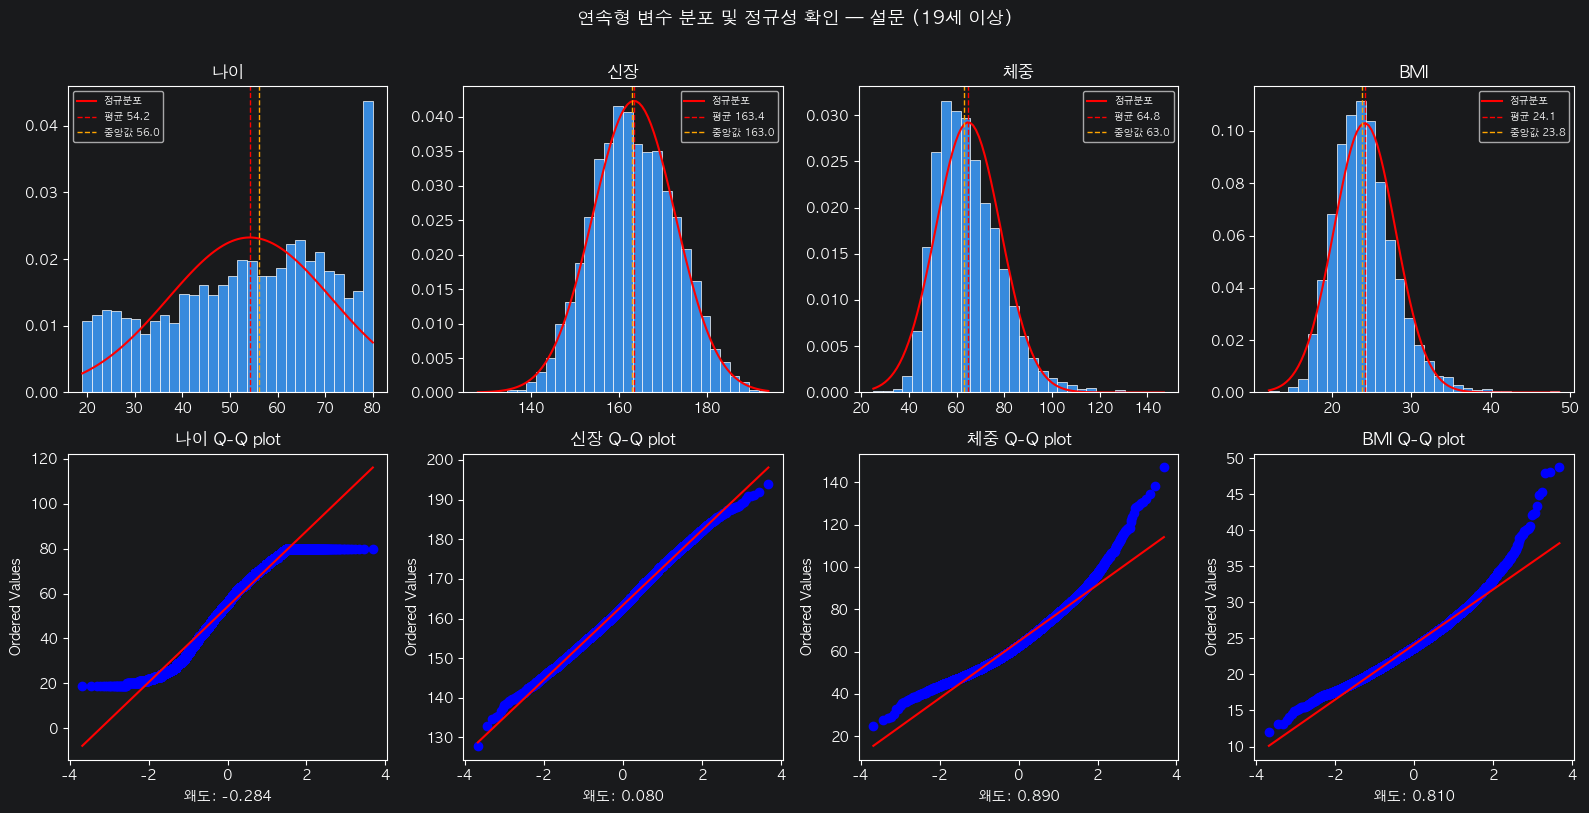

저장 완료: 01a_연속형변수분포.png


In [7]:
# ── 연속형 변수 분포 시각화 — 설문 4개 (히스토그램 + Q-Q) ────
base_cols = ['나이', '신장', '체중', 'BMI']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for j, col in enumerate(base_cols):
    data = df[col].dropna()

    axes[0][j].hist(data, bins=30, color='#378ADD', edgecolor='white', linewidth=0.5, density=True)
    mu, std = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    axes[0][j].plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=1.5, label='정규분포')
    axes[0][j].axvline(mu, color='red', linestyle='--', linewidth=1, label=f'평균 {mu:.1f}')
    axes[0][j].axvline(data.median(), color='orange', linestyle='--', linewidth=1, label=f'중앙값 {data.median():.1f}')
    axes[0][j].set_title(col)
    axes[0][j].legend(fontsize=7)

    stats.probplot(data, dist='norm', plot=axes[1][j])
    axes[1][j].set_title(f'{col} Q-Q plot')
    axes[1][j].set_xlabel(f'왜도: {data.skew():.3f}')

plt.suptitle('연속형 변수 분포 및 정규성 확인 — 설문 (19세 이상)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01a_연속형변수분포.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 01a_연속형변수분포.png')

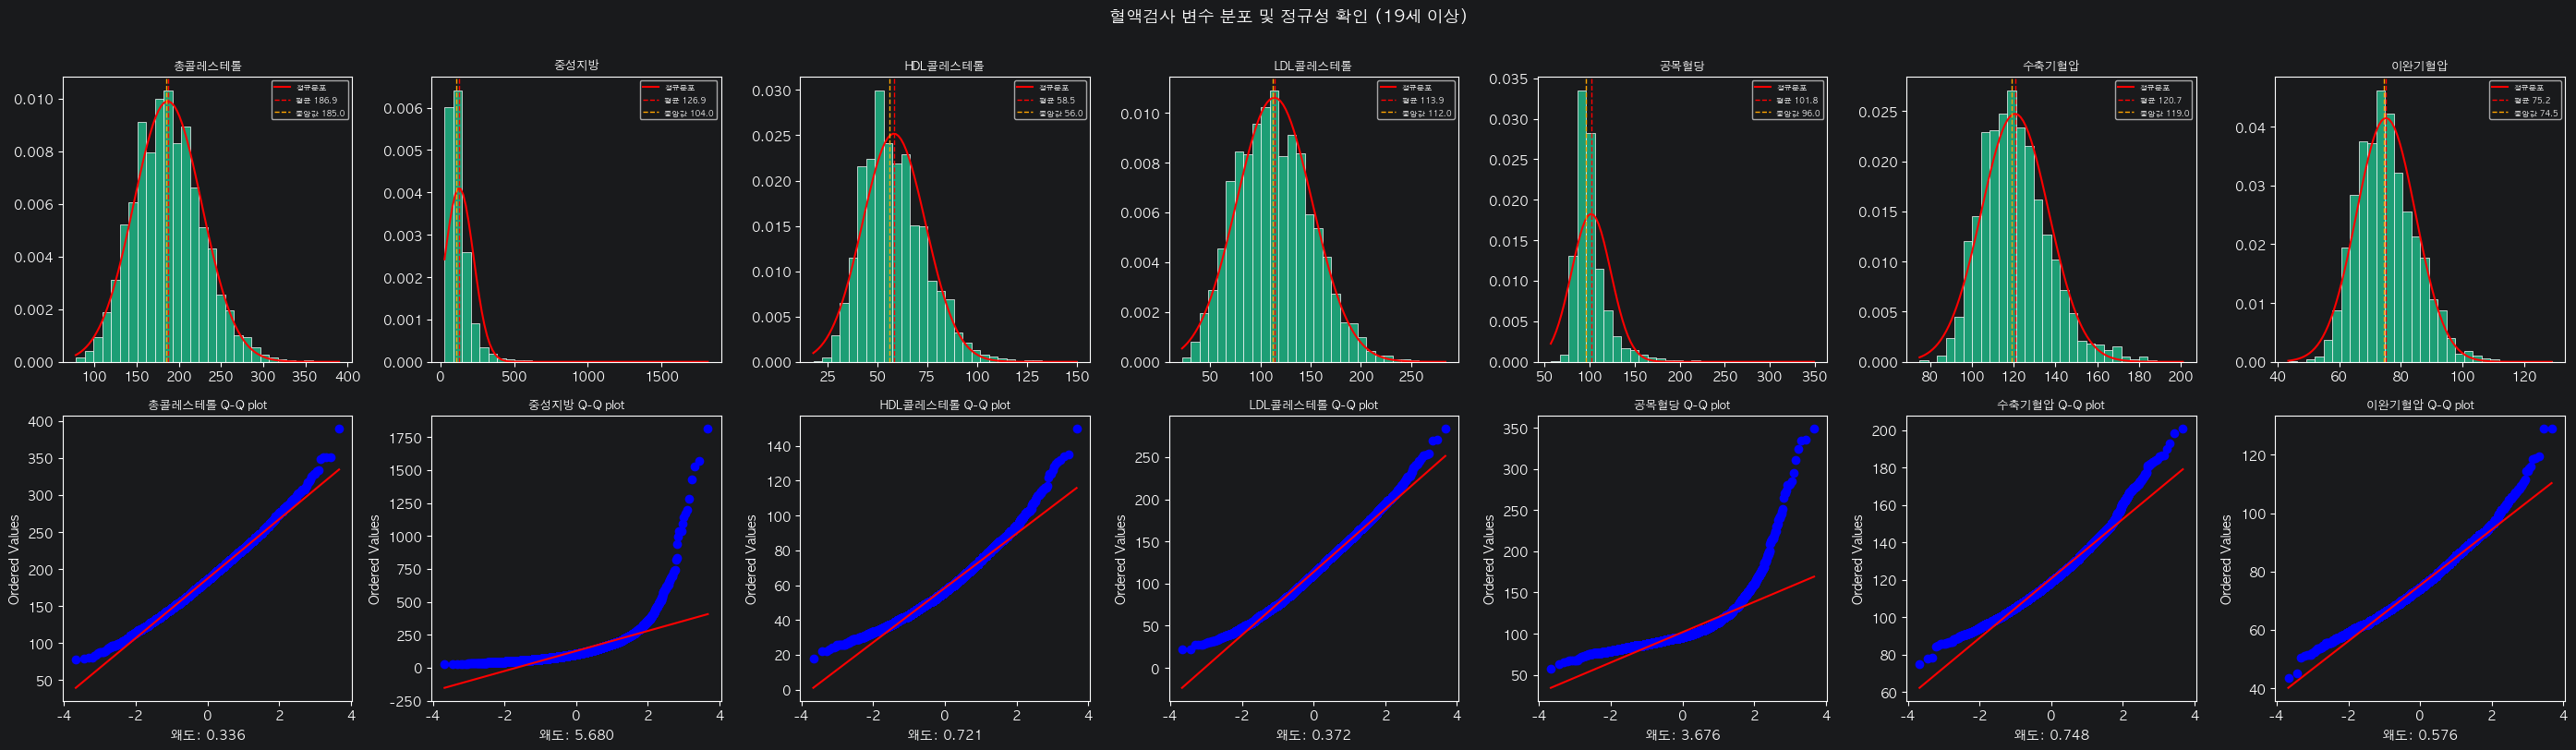

저장 완료: 01b_혈액검사변수분포.png


In [8]:
# ── 혈액검사 변수 분포 시각화 (히스토그램 + Q-Q) ─────────────
blood_cols = ['총콜레스테롤', '중성지방', 'HDL콜레스테롤', 'LDL콜레스테롤',
              '공복혈당', '수축기혈압', '이완기혈압']

fig, axes = plt.subplots(2, 7, figsize=(28, 8))

for j, col in enumerate(blood_cols):
    data = df[col].dropna()

    axes[0][j].hist(data, bins=30, color='#1D9E75', edgecolor='white', linewidth=0.5, density=True)
    mu, std = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    axes[0][j].plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=1.5, label='정규분포')
    axes[0][j].axvline(mu, color='red', linestyle='--', linewidth=1, label=f'평균 {mu:.1f}')
    axes[0][j].axvline(data.median(), color='orange', linestyle='--', linewidth=1, label=f'중앙값 {data.median():.1f}')
    axes[0][j].set_title(col, fontsize=9)
    axes[0][j].legend(fontsize=6)

    stats.probplot(data, dist='norm', plot=axes[1][j])
    axes[1][j].set_title(f'{col} Q-Q plot', fontsize=9)
    axes[1][j].set_xlabel(f'왜도: {data.skew():.3f}')

plt.suptitle('혈액검사 변수 분포 및 정규성 확인 (19세 이상)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01b_혈액검사변수분포.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 01b_혈액검사변수분포.png')

## 2. Y값별 분포 비교

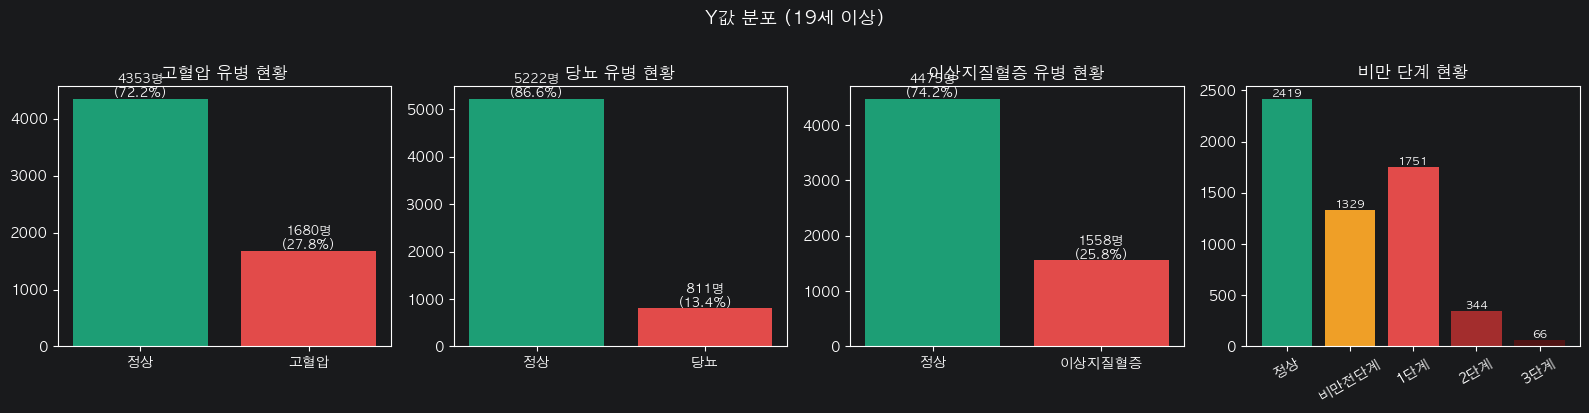

저장 완료: 02_Y값분포.png


In [9]:
# ── Y값 전체 분포 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col, title in zip(
    axes[:3],
    ['고혈압유병', '당뇨유병', '이상지질혈증유병'],
    ['고혈압', '당뇨', '이상지질혈증']
):
    vc = df[col].value_counts().sort_index()
    ax.bar(['정상', title], vc.values, color=['#1D9E75', '#E24B4A'])
    ax.set_title(f'{title} 유병 현황')
    for i, v in enumerate(vc.values):
        ax.text(i, v + 30, f'{v}명\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

obe = df['비만단계'].value_counts().sort_index()
obe_labels = {2: '정상', 3: '비만전단계', 4: '1단계', 5: '2단계', 6: '3단계'}
obe.index = [obe_labels.get(i, str(i)) for i in obe.index]
axes[3].bar(obe.index, obe.values, color=['#1D9E75', '#EF9F27', '#E24B4A', '#A32D2D', '#501313'])
axes[3].set_title('비만 단계 현황')
for i, v in enumerate(obe.values):
    axes[3].text(i, v + 20, f'{v}', ha='center', fontsize=8)
axes[3].tick_params(axis='x', rotation=30)

plt.suptitle('Y값 분포 (19세 이상)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_Y값분포.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 02_Y값분포.png')

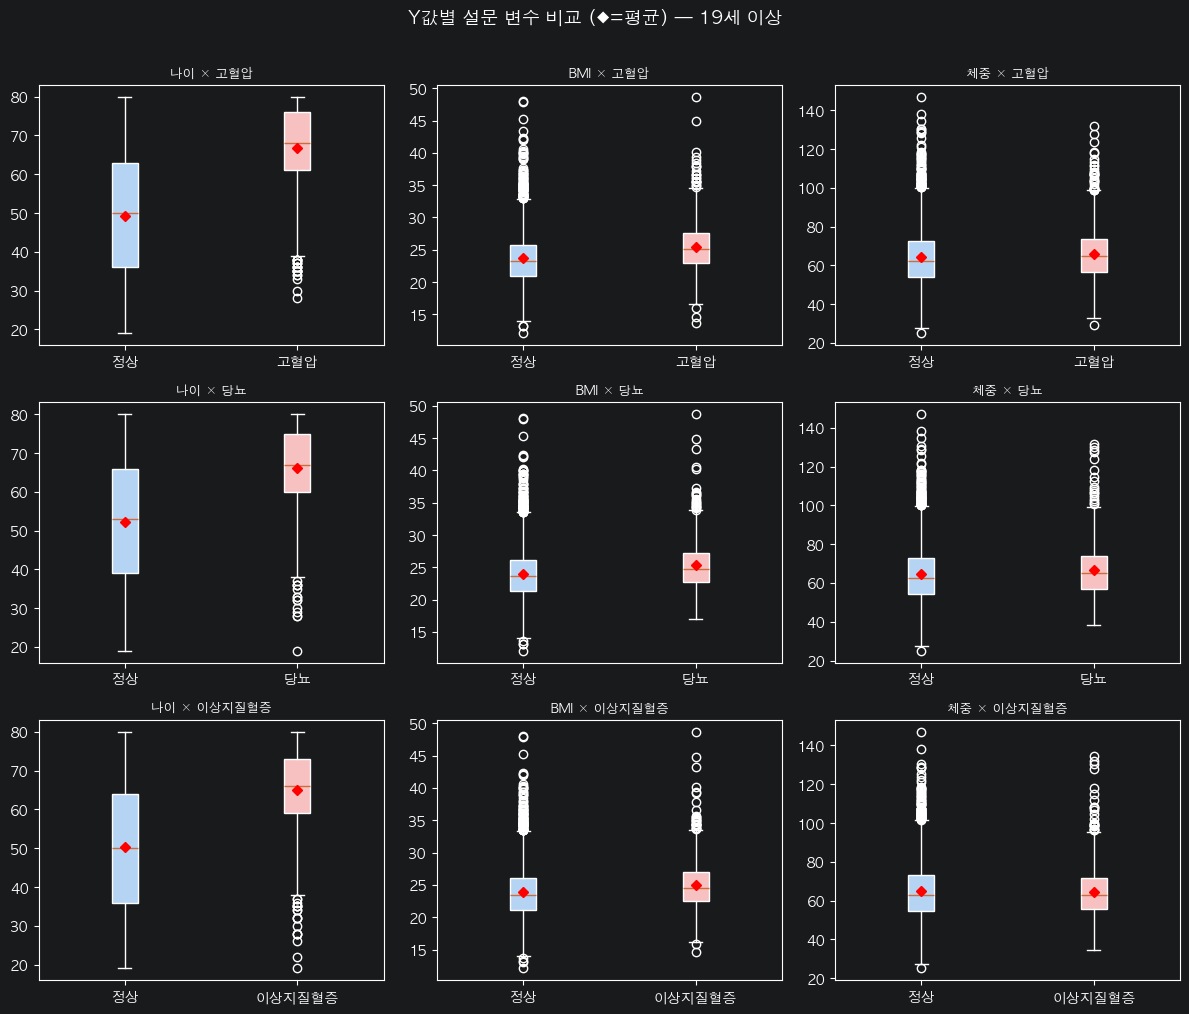

저장 완료: 03a_Y값별설문비교.png


In [10]:
# ── Y값별 연속형 변수 비교 (boxplot) — 설문 변수 ─────────────
y_vars = {'고혈압유병': '고혈압', '당뇨유병': '당뇨', '이상지질혈증유병': '이상지질혈증'}
x_vars_survey = ['나이', 'BMI', '체중']

fig, axes = plt.subplots(len(y_vars), len(x_vars_survey), figsize=(12, 10))
for i, (y_col, y_label) in enumerate(y_vars.items()):
    for j, x_col in enumerate(x_vars_survey):
        data = [df[df[y_col]==0][x_col].dropna(), df[df[y_col]==1][x_col].dropna()]
        bp = axes[i][j].boxplot(data, tick_labels=['정상', y_label], patch_artist=True)
        bp['boxes'][0].set_facecolor('#B5D4F4')
        bp['boxes'][1].set_facecolor('#F7C1C1')
        axes[i][j].set_title(f'{x_col} × {y_label}', fontsize=9)
        for k, d in enumerate(data):
            axes[i][j].plot(k+1, d.mean(), 'D', color='red', markersize=5, zorder=5)

plt.suptitle('Y값별 설문 변수 비교 (◆=평균) — 19세 이상', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03a_Y값별설문비교.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 03a_Y값별설문비교.png')

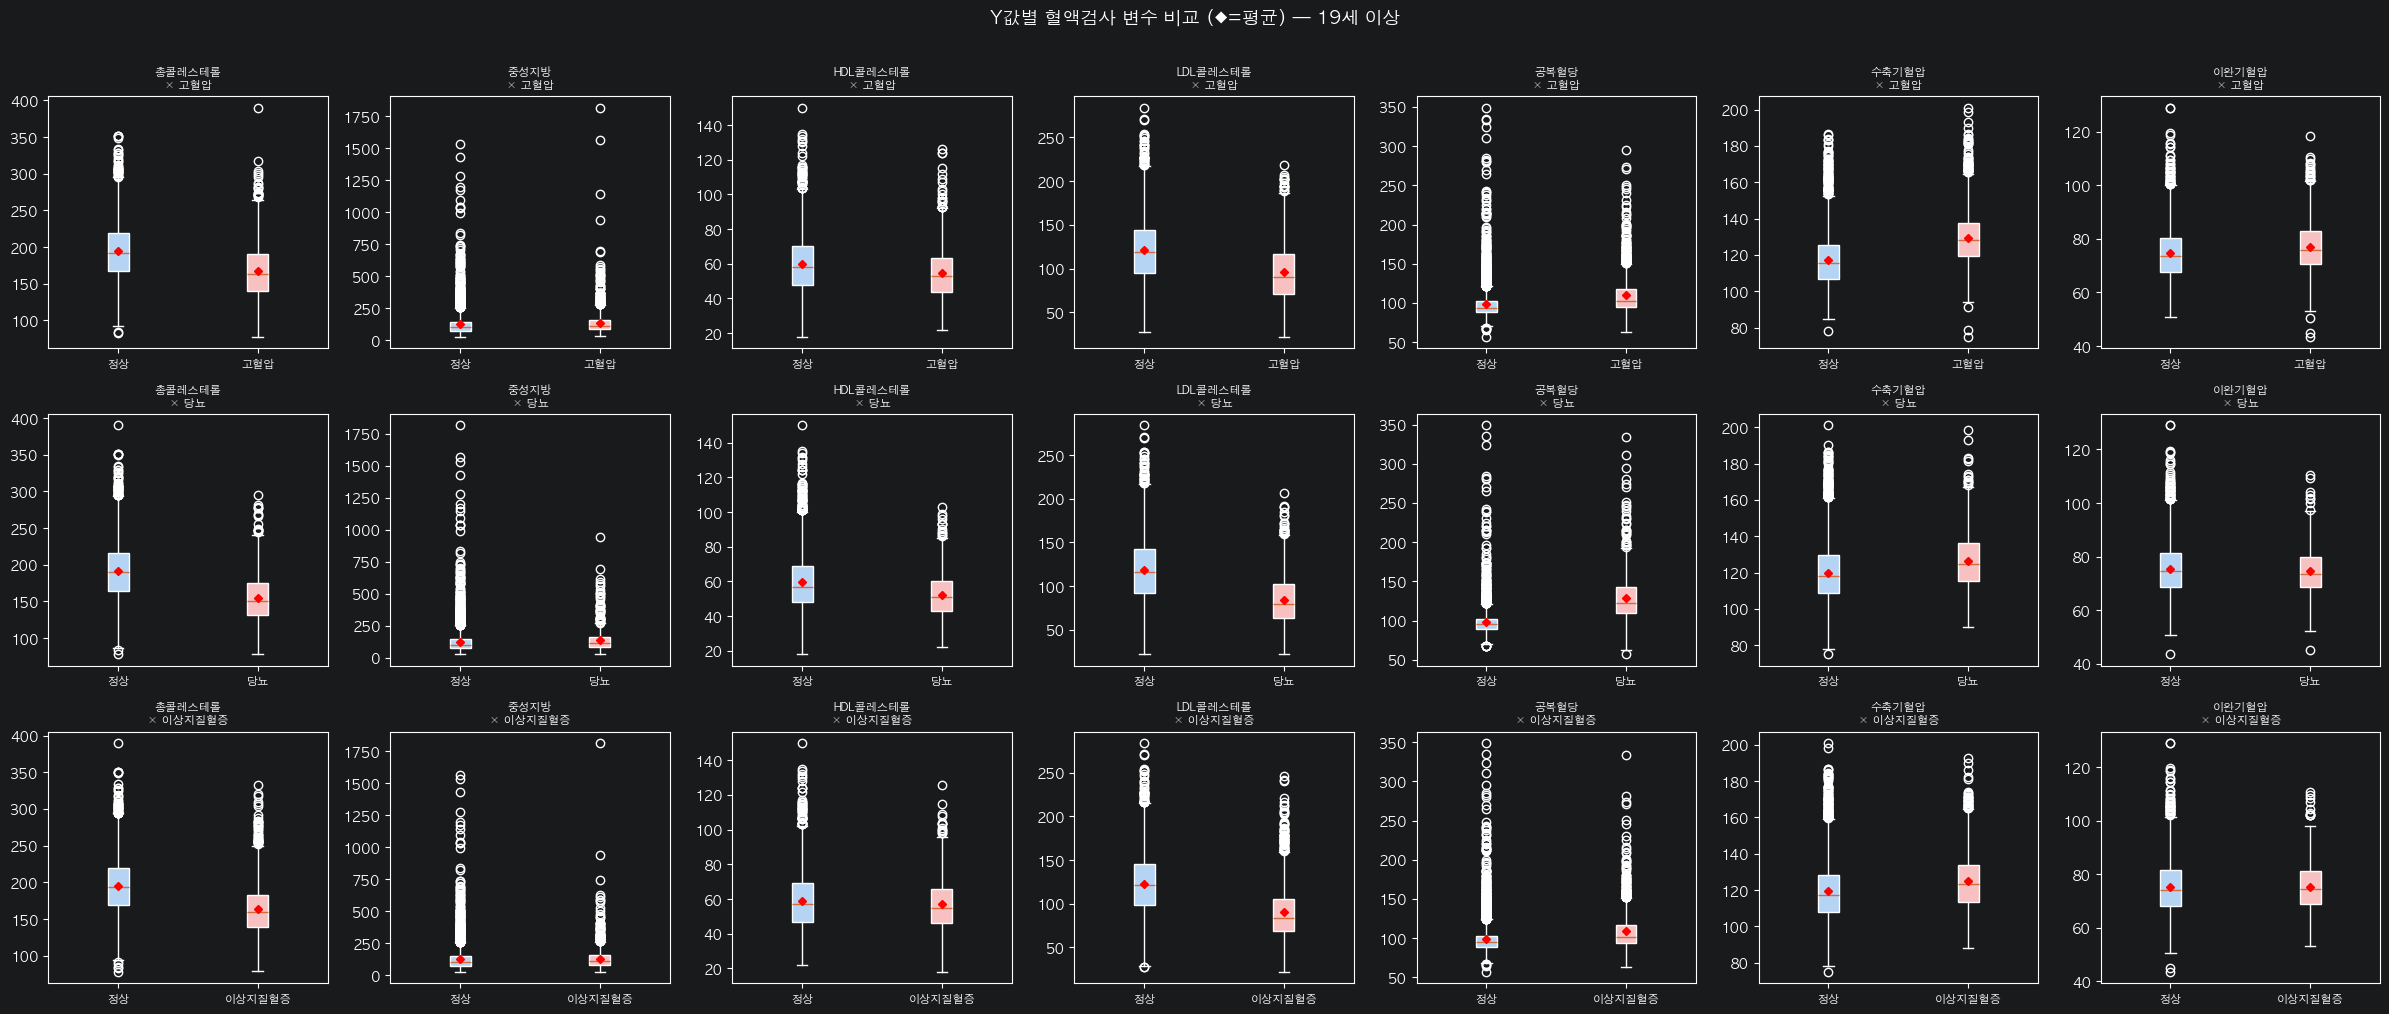

저장 완료: 03b_Y값별혈액검사비교.png


In [11]:
# ── Y값별 연속형 변수 비교 (boxplot) — 혈액검사 변수 ──────────
y_vars = {'고혈압유병': '고혈압', '당뇨유병': '당뇨', '이상지질혈증유병': '이상지질혈증'}
x_vars_blood = ['총콜레스테롤', '중성지방', 'HDL콜레스테롤', 'LDL콜레스테롤',
                '공복혈당', '수축기혈압', '이완기혈압']

fig, axes = plt.subplots(len(y_vars), len(x_vars_blood), figsize=(24, 10))
for i, (y_col, y_label) in enumerate(y_vars.items()):
    for j, x_col in enumerate(x_vars_blood):
        data = [df[df[y_col]==0][x_col].dropna(), df[df[y_col]==1][x_col].dropna()]
        bp = axes[i][j].boxplot(data, tick_labels=['정상', y_label], patch_artist=True)
        bp['boxes'][0].set_facecolor('#B5D4F4')
        bp['boxes'][1].set_facecolor('#F7C1C1')
        axes[i][j].set_title(f'{x_col}\n× {y_label}', fontsize=8)
        for k, d in enumerate(data):
            axes[i][j].plot(k+1, d.mean(), 'D', color='red', markersize=4, zorder=5)
        axes[i][j].tick_params(axis='x', labelsize=8)

plt.suptitle('Y값별 혈액검사 변수 비교 (◆=평균) — 19세 이상', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03b_Y값별혈액검사비교.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 03b_Y값별혈액검사비교.png')

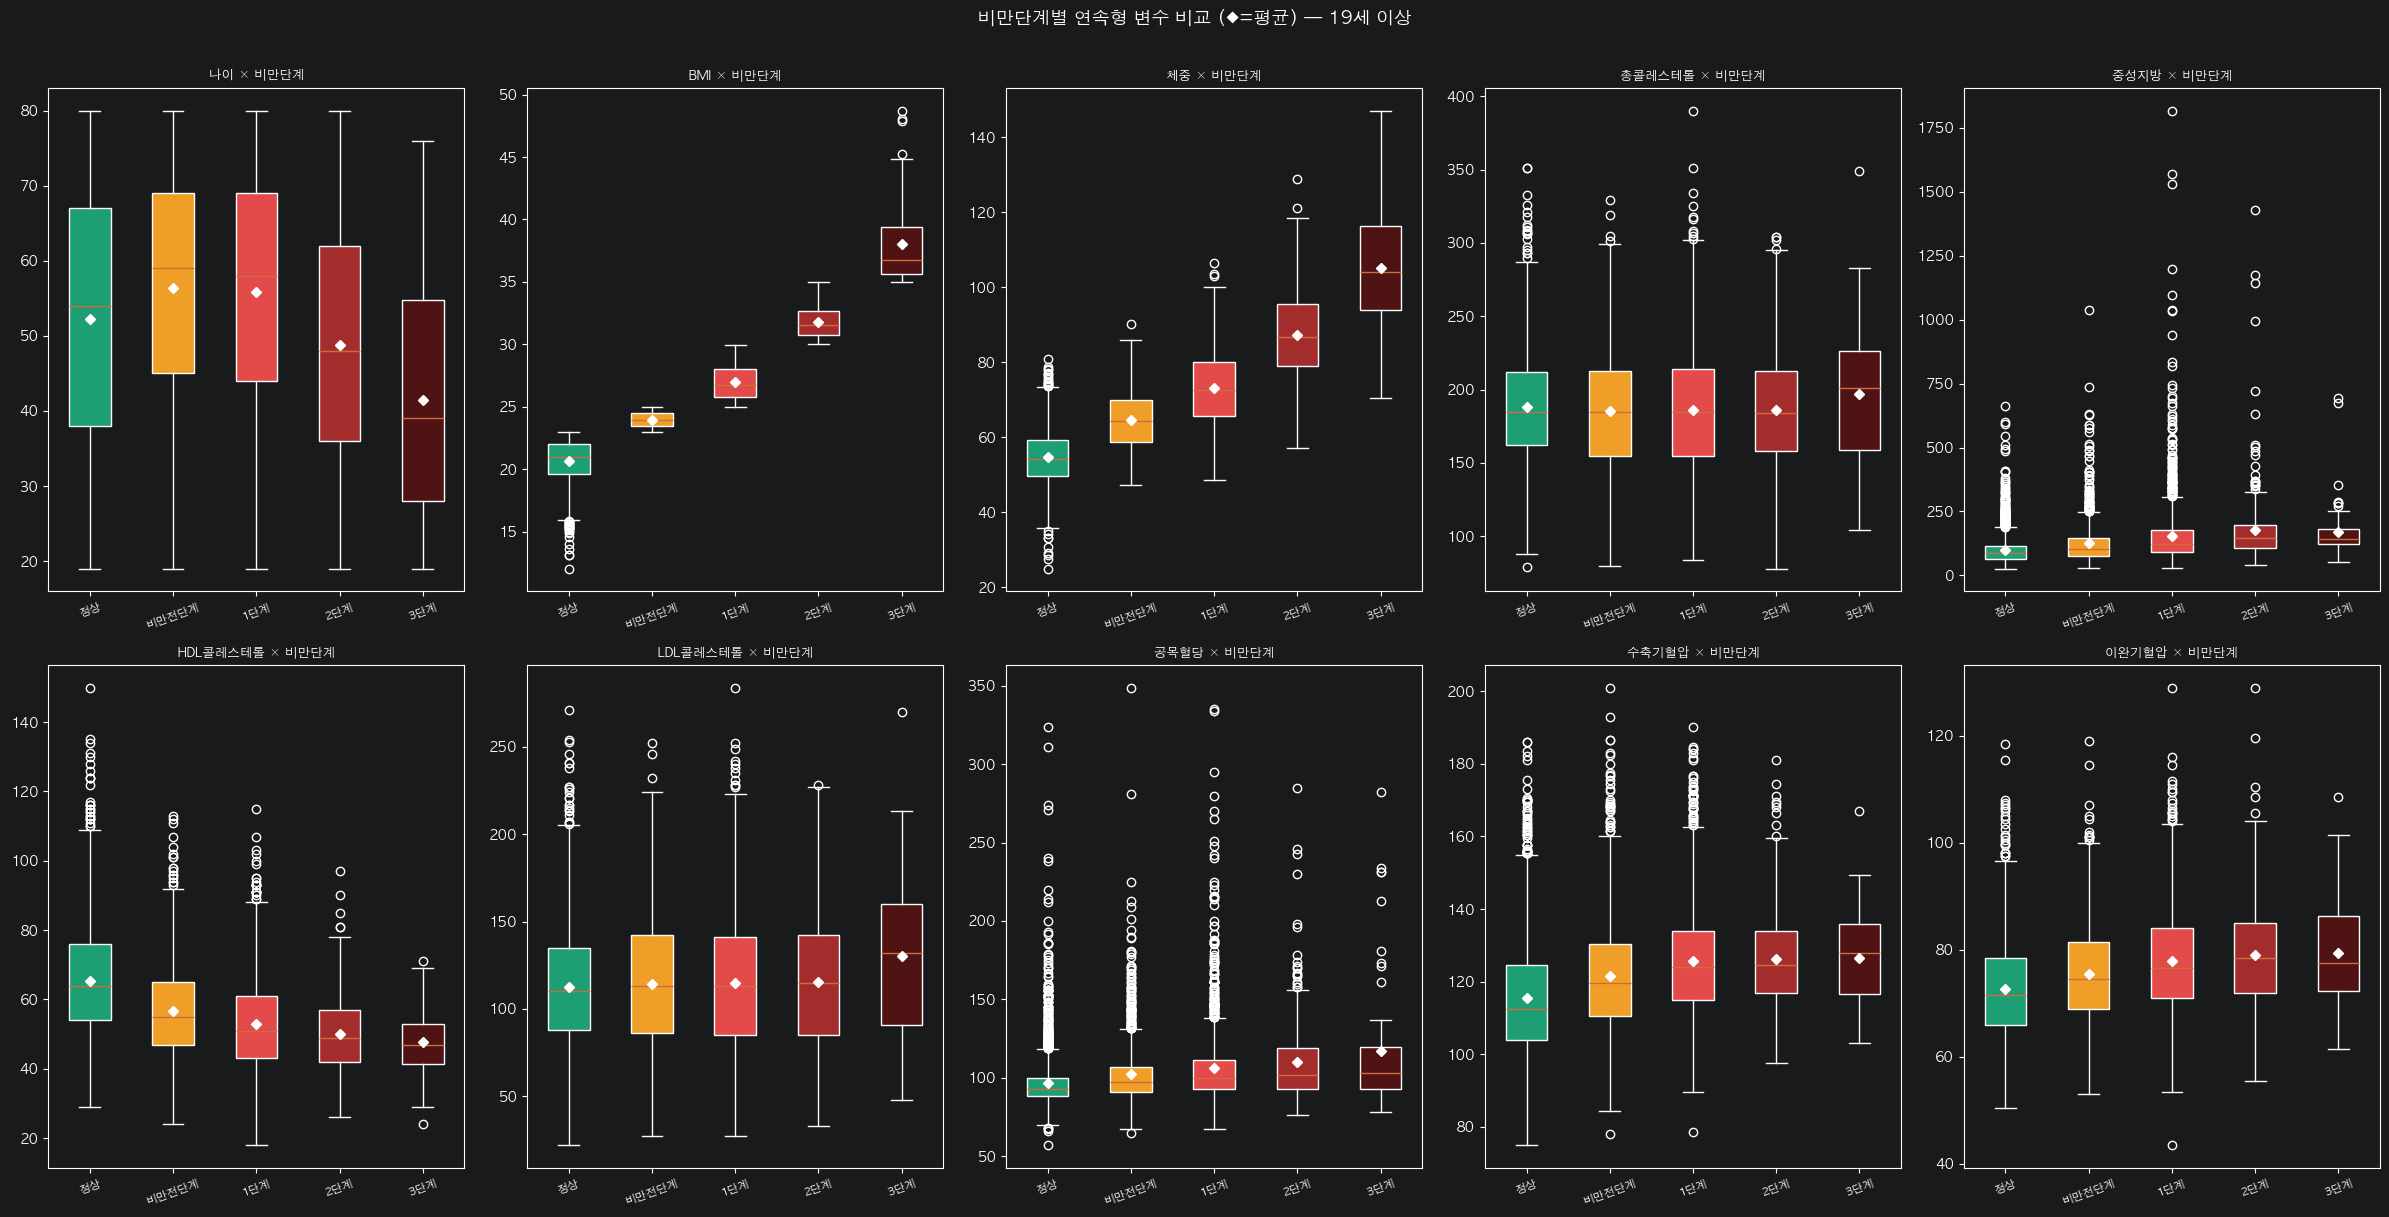

저장 완료: 03c_비만단계별연속형비교.png


In [12]:
# ── 비만단계별 연속형 변수 비교 (boxplot) ────────────────────
obe_labels = {2: '정상', 3: '비만전단계', 4: '1단계', 5: '2단계', 6: '3단계'}
obe_stages = sorted(obe_labels.keys())
obe_names = [obe_labels[k] for k in obe_stages]
colors = ['#1D9E75', '#EF9F27', '#E24B4A', '#A32D2D', '#501313']

x_vars_all = ['나이', 'BMI', '체중',
              '총콜레스테롤', '중성지방', 'HDL콜레스테롤', 'LDL콜레스테롤',
              '공복혈당', '수축기혈압', '이완기혈압']

fig, axes = plt.subplots(2, 5, figsize=(24, 12))
axes_flat = axes.flatten()

for j, x_col in enumerate(x_vars_all):
    data = [df[df['비만단계']==stage][x_col].dropna() for stage in obe_stages]
    bp = axes_flat[j].boxplot(data, tick_labels=obe_names, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    axes_flat[j].set_title(f'{x_col} × 비만단계', fontsize=9)
    axes_flat[j].tick_params(axis='x', rotation=20, labelsize=8)
    for k, d in enumerate(data):
        axes_flat[j].plot(k+1, d.mean(), 'D', color='white', markersize=5, zorder=5)

plt.suptitle('비만단계별 연속형 변수 비교 (◆=평균) — 19세 이상', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03c_비만단계별연속형비교.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 03c_비만단계별연속형비교.png')

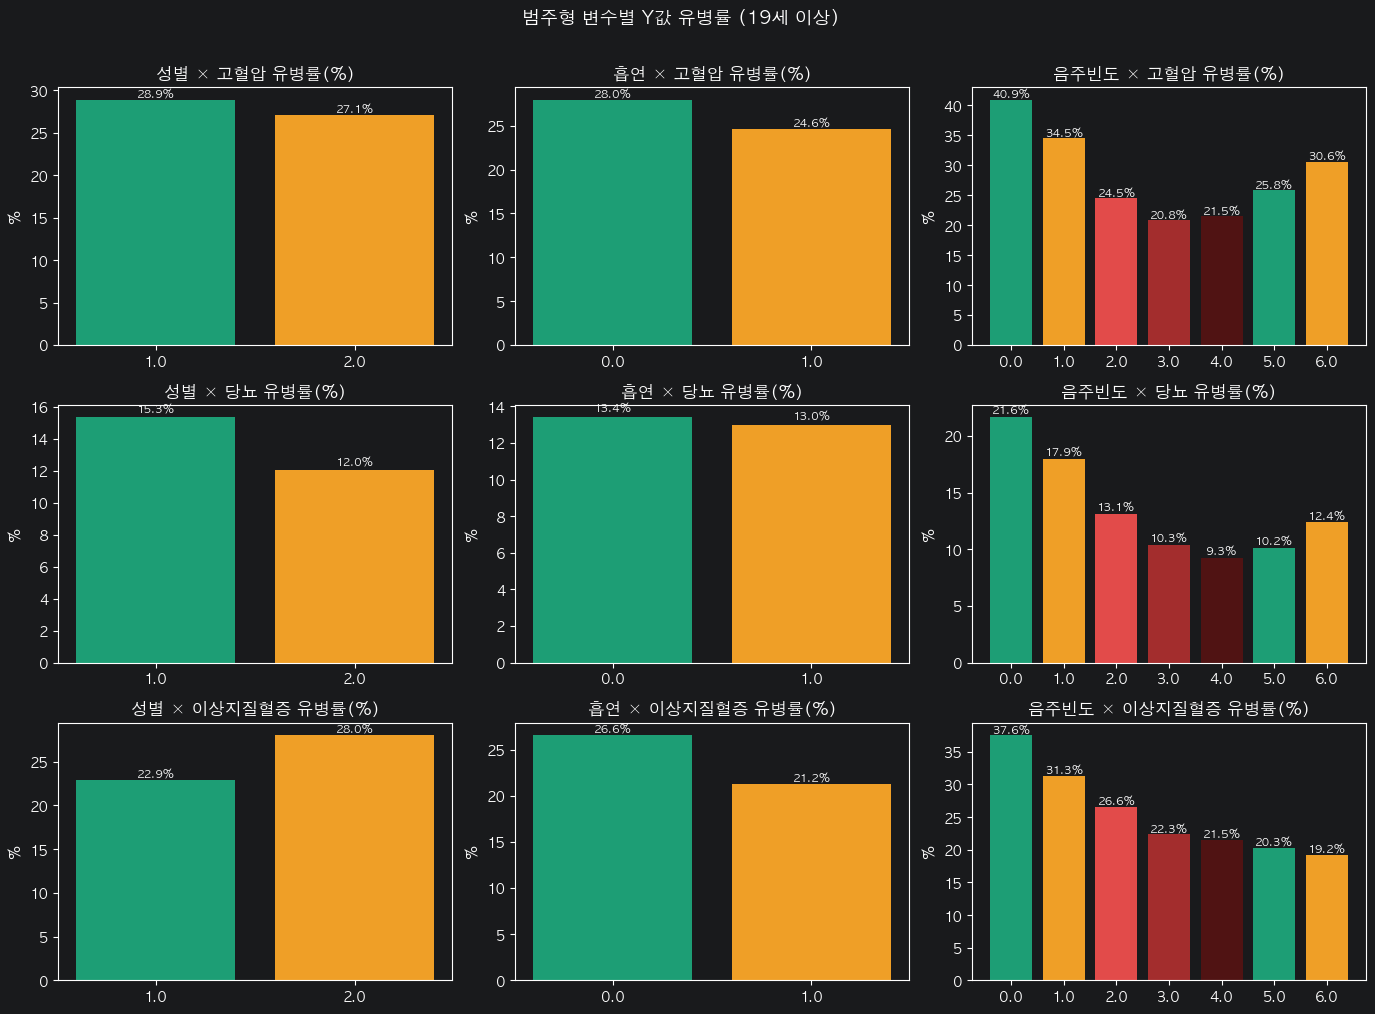

저장 완료: 04_범주형유병률.png


In [13]:
# ── Y값별 성별/흡연/음주 유병률 비교 ─────────────────────────
y_vars = {'고혈압유병': '고혈압', '당뇨유병': '당뇨', '이상지질혈증유병': '이상지질혈증'}
cat_y = {'성별': '성별', '현재흡연': '흡연', '음주빈도': '음주빈도'}

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, (y_col, y_label) in enumerate(y_vars.items()):
    for j, (x_col, x_label) in enumerate(cat_y.items()):
        ct = pd.crosstab(df[x_col], df[y_col], normalize='index') * 100
        if 1.0 in ct.columns:
            bars = axes[i][j].bar(ct.index.astype(str), ct[1.0], color=['#1D9E75', '#EF9F27', '#E24B4A', '#A32D2D', '#501313'])
            axes[i][j].set_title(f'{x_label} × {y_label} 유병률(%)')
            axes[i][j].set_ylabel('%')
            for bar, val in zip(bars, ct[1.0]):
                axes[i][j].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                                f'{val:.1f}%', ha='center', fontsize=8)

plt.suptitle('범주형 변수별 Y값 유병률 (19세 이상)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_범주형유병률.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 04_범주형유병률.png')

## 3. 결측 패턴 분석

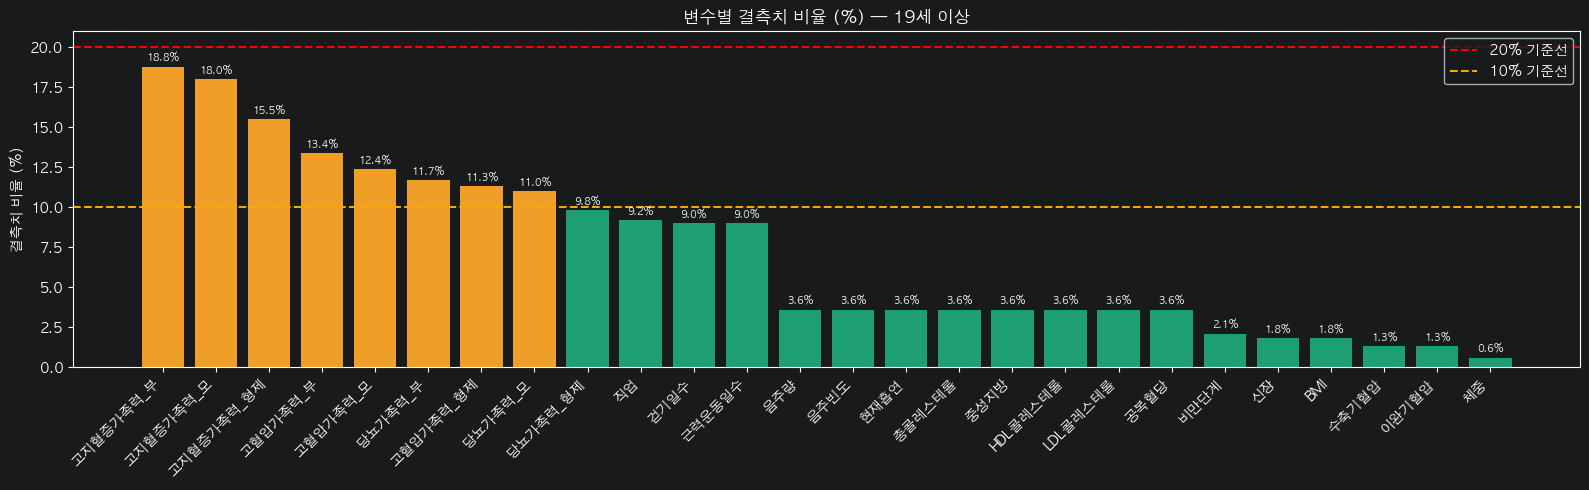

저장 완료: 05_결측률.png


In [14]:
# ── 결측률 바 차트 ────────────────────────────────────────────
miss_pct = (df.isnull().sum() / len(df) * 100).round(1)
miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=False)

colors_miss = ['#E24B4A' if x > 20 else '#EF9F27' if x > 10 else '#1D9E75' for x in miss_pct]

plt.figure(figsize=(16, 5))
bars = plt.bar(miss_pct.index, miss_pct.values, color=colors_miss)
plt.xticks(rotation=45, ha='right')
plt.title('변수별 결측치 비율 (%) — 19세 이상')
plt.ylabel('결측치 비율 (%)')
plt.axhline(y=20, color='red', linestyle='--', label='20% 기준선')
plt.axhline(y=10, color='orange', linestyle='--', label='10% 기준선')
for bar, val in zip(bars, miss_pct.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', fontsize=7)
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_결측률.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 05_결측률.png')

In [15]:
# ── 가족력 결측 패턴 ──────────────────────────────────────────
fh_cols = ['고혈압가족력_부', '고혈압가족력_모', '고혈압가족력_형제',
           '당뇨가족력_부', '당뇨가족력_모', '당뇨가족력_형제',
           '고지혈증가족력_부', '고지혈증가족력_모', '고지혈증가족력_형제']

miss_pattern = df[fh_cols].isnull().sum(axis=1).value_counts().sort_index()
print('가족력 변수 중 동시 결측 개수 분포:')
print(miss_pattern)
print(f'\n가족력 9개 모두 결측인 사람: {df[fh_cols].isnull().all(axis=1).sum()}명')
print(f'가족력 모두 있는 사람: {(df[fh_cols].isnull().any(axis=1) == False).sum()}명')

가족력 변수 중 동시 결측 개수 분포:
0    4741
1      88
2     150
3     251
4      68
5      58
6     121
7      23
8      33
9     500
Name: count, dtype: int64

가족력 9개 모두 결측인 사람: 500명
가족력 모두 있는 사람: 4741명


In [16]:
# ── 혈액검사 결측 패턴 ────────────────────────────────────────
blood_cols = ['총콜레스테롤', '중성지방', 'HDL콜레스테롤', 'LDL콜레스테롤',
              '공복혈당', '수축기혈압', '이완기혈압']

miss_blood = df[blood_cols].isnull().sum(axis=1).value_counts().sort_index()
print('혈액검사 변수 중 동시 결측 개수 분포:')
print(miss_blood)
print(f'\n혈액검사 전체 결측 (검진 미참여 추정): {df[blood_cols].isnull().all(axis=1).sum()}명')
print(f'혈액검사 모두 있는 사람: {df[blood_cols].isnull().any(axis=1).eq(False).sum()}명')

혈액검사 변수 중 동시 결측 개수 분포:
0    5763
2      51
5     194
7      25
Name: count, dtype: int64

혈액검사 전체 결측 (검진 미참여 추정): 25명
혈액검사 모두 있는 사람: 5763명


## 4. 변수간 상관관계

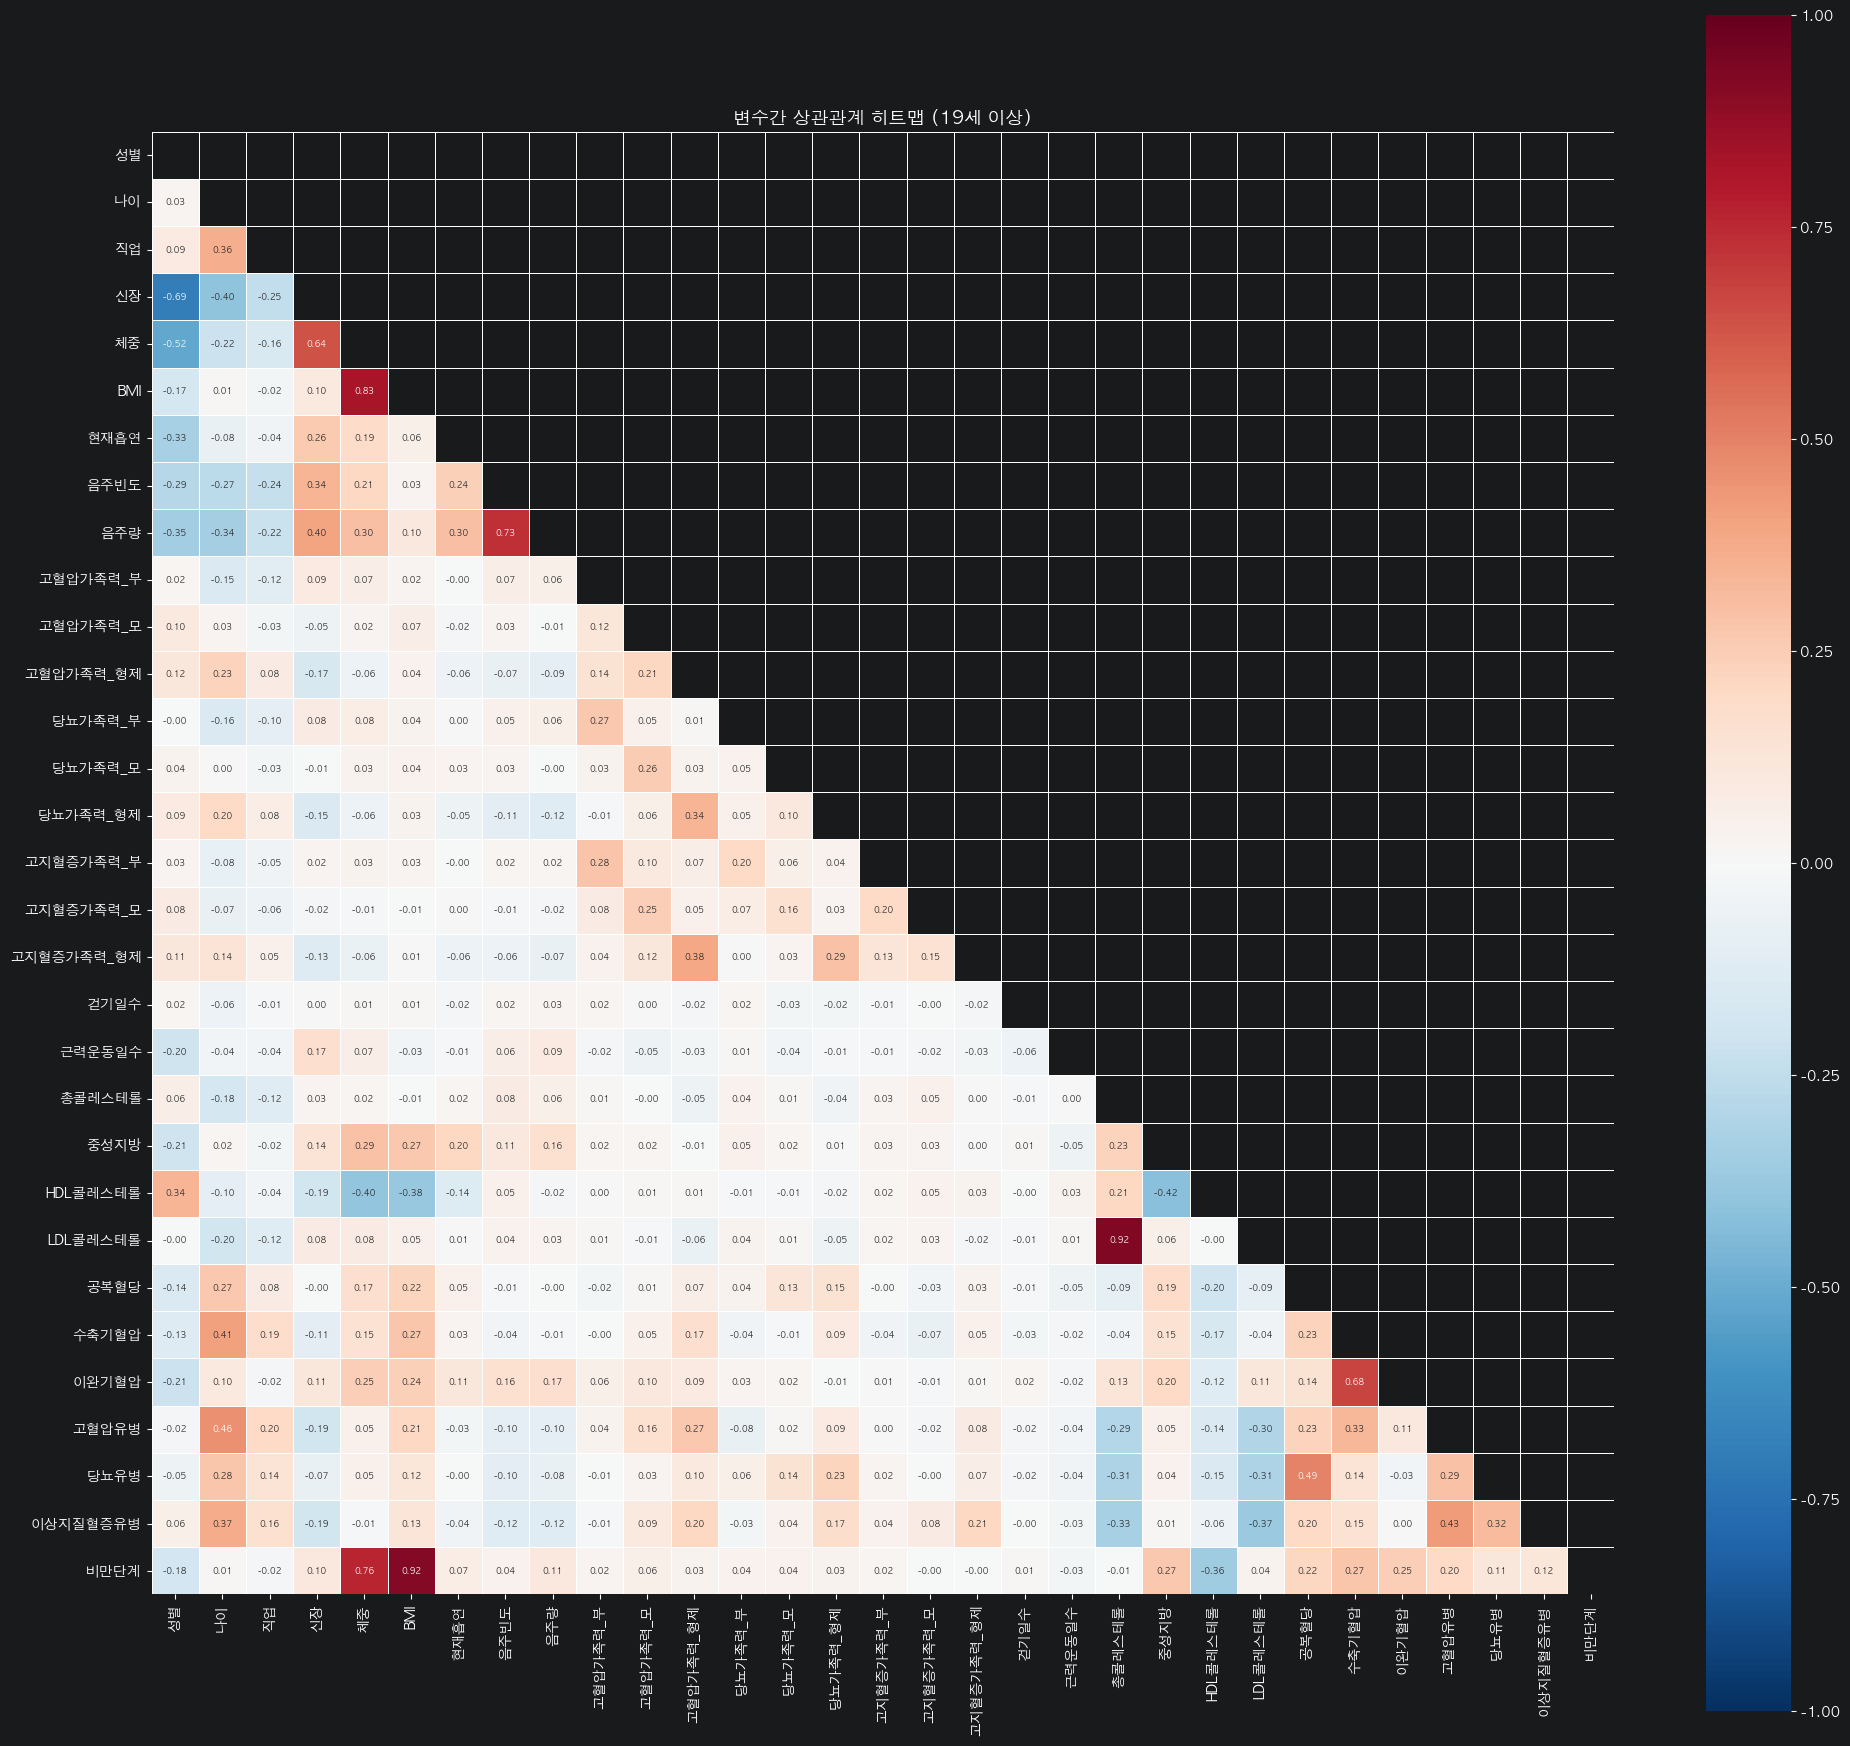

저장 완료: 06_전체상관관계.png


In [17]:
# ── 전체 상관관계 히트맵 ──────────────────────────────────────
num_cols = [c for c in df.columns if c != 'ID']
corr = df[num_cols].corr()

plt.figure(figsize=(20, 18))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 6}, square=True)
plt.title('변수간 상관관계 히트맵 (19세 이상)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_전체상관관계.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 06_전체상관관계.png')

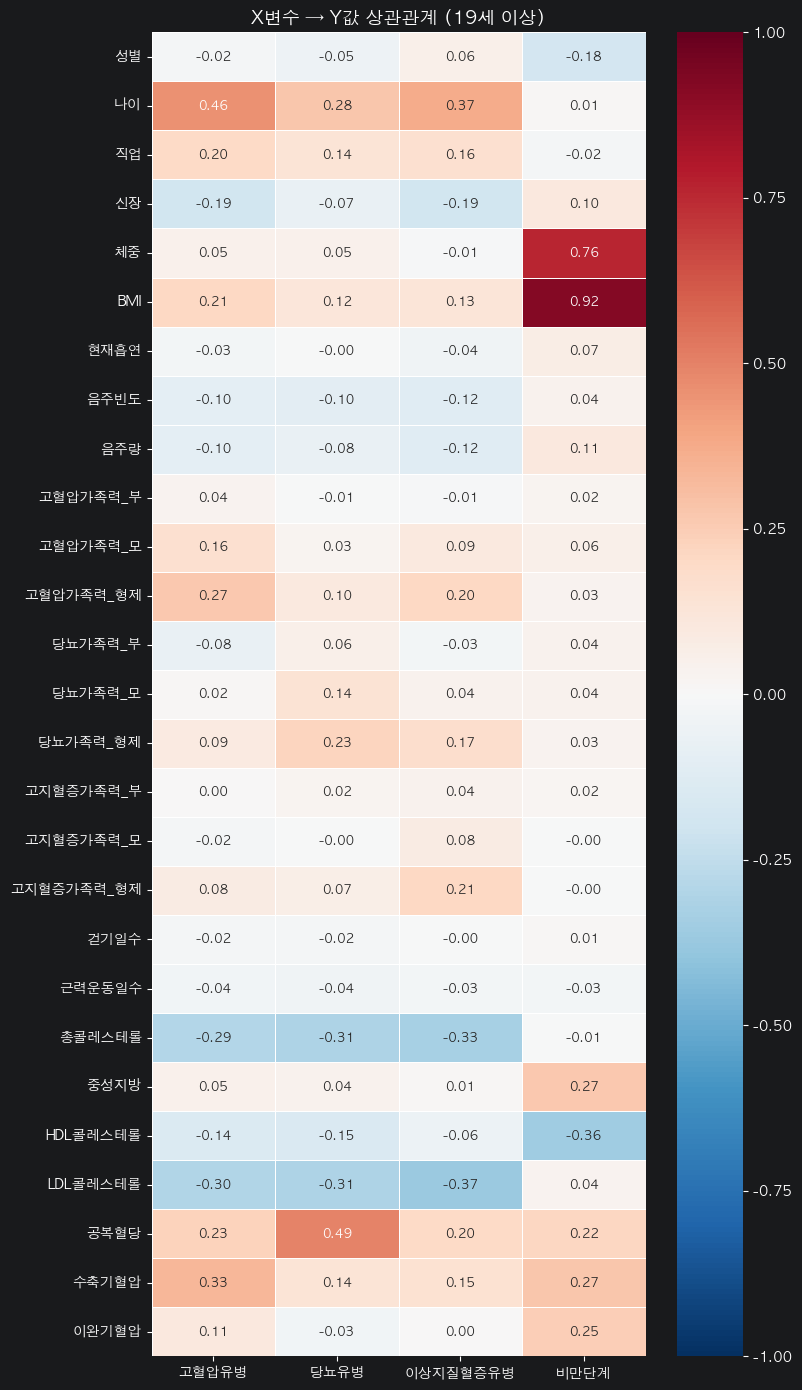

저장 완료: 07_Y값상관관계.png


In [18]:
# ── Y값과 X변수간 상관관계 ────────────────────────────────────
y_cols = ['고혈압유병', '당뇨유병', '이상지질혈증유병', '비만단계']
x_cols = [c for c in num_cols if c not in y_cols and c != 'ID']

corr_y = df[x_cols + y_cols].corr()[y_cols].drop(y_cols)

plt.figure(figsize=(8, 14))
sns.heatmap(corr_y, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('X변수 → Y값 상관관계 (19세 이상)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_Y값상관관계.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 07_Y값상관관계.png')

In [19]:
# ── Y값별 상관관계 Top5 ───────────────────────────────────────
print('=== Y값별 상관관계 Top5 X변수 (19세 이상) ===')
for y in y_cols:
    top5 = corr_y[y].abs().sort_values(ascending=False).head(5)
    print(f'\n{y}:')
    for var, val in top5.items():
        print(f'  {var:20s}: {corr_y[y][var]:+.3f}')

print(f'\n=== 전체 저장 완료 ===')
print(f'저장 위치: {OUTPUT_DIR}')
saved = sorted([f for f in os.listdir(OUTPUT_DIR) if f.endswith('.png')])
for f in saved:
    print(f'  {f}')

=== Y값별 상관관계 Top5 X변수 (19세 이상) ===

고혈압유병:
  나이                  : +0.461
  수축기혈압               : +0.331
  LDL콜레스테롤            : -0.300
  총콜레스테롤              : -0.294
  고혈압가족력_형제           : +0.271

당뇨유병:
  공복혈당                : +0.494
  총콜레스테롤              : -0.310
  LDL콜레스테롤            : -0.305
  나이                  : +0.275
  당뇨가족력_형제            : +0.225

이상지질혈증유병:
  나이                  : +0.372
  LDL콜레스테롤            : -0.370
  총콜레스테롤              : -0.335
  고지혈증가족력_형제          : +0.205
  고혈압가족력_형제           : +0.205

비만단계:
  BMI                 : +0.920
  체중                  : +0.764
  HDL콜레스테롤            : -0.358
  수축기혈압               : +0.274
  중성지방                : +0.269

=== 전체 저장 완료 ===
저장 위치: /Users/admin/PycharmProjects/chronic-health/outputs_file2_adult
  01a_연속형변수분포.png
  01b_혈액검사변수분포.png
  01c_범주형변수분포.png
  02_Y값분포.png
  03a_Y값별설문비교.png
  03b_Y값별혈액검사비교.png
  03c_비만단계별연속형비교.png
  04_범주형유병률.png
  05_결측률.png
  06_전체상관관계.png
  07_Y값상관관계.png
